In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# Vision Transformer (ViT)

**Paper:** [arXiv:2010.11929](https://arxiv.org/abs/2010.11929) — *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale* (Dosovitskiy et al., Google Brain, 2020).  
**HF source:** [google/vit-base-patch16-224](https://huggingface.co/google/vit-base-patch16-224)

This notebook walks through a **from-scratch JAX implementation** of ViT-Base/16.

---

### Paper Overview

ViT's central claim: **pure Transformers can match or outperform CNNs on image classification** when trained on sufficient data — no convolutions needed. The key insight is to split an image into fixed-size patches and treat them as a 1D token sequence, exactly like words in NLP.

| Innovation | What it solves |
|---|---|
| **Patch tokenisation** | Converts 2D images into a flat sequence for Transformers |
| **[CLS] token** | Single learnable token that aggregates the global image representation |
| **Learnable positional embeddings** | Lets the model learn spatial relationships between patches |
| **Pre-norm Transformer blocks** | LayerNorm *before* attention/MLP — more stable training |

### Architecture at a glance (ViT-Base/16)

```
Input (224×224×3)
  ↓  Split into 196 patches of 16×16px
  ↓  Linear projection: 768-dim patch embeddings    → (196, 768)
  ↓  Prepend [CLS] token                            → (197, 768)
  ↓  Add learnable positional embeddings            → (197, 768)
  ↓  12× Transformer Encoder Block:
       LayerNorm → MHSA (12 heads, d_head=64) → Residual
       LayerNorm → MLP  (768→3072→768, GELU)  → Residual
  ↓  Final LayerNorm
  ↓  Extract [CLS] token → (768,)
  ↓  Linear classifier  → 1000 classes
```


### Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import tree_util
import PIL.Image as Image
from safetensors.numpy import load_file
from transformers import AutoTokenizer
from einops import rearrange, repeat

**Setup:** Download the model weights and config from HuggingFace and place them at `models/vit/` relative to your workspace root

In [ ]:
HF_REPO_ID = "google/vit-base-patch16-224"
LOCAL_DIR_PATH = "workspace/models/vit"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)

print(f"Downloaded repository path: {local_dir}")

### Load Weights

We load the ViT-Base/16 weights from a local `.safetensors` file (downloaded from HuggingFace) along with the model config. The `id2label` map in the config gives us ImageNet class names for free.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
LABELS_PATH = f"{LOCAL_DIR_PATH}/id2label.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

# Load the raw state dict
hf_weights = load_file(WEIGHTS_PATH)

with open(CONFIG_PATH, 'r') as f:
    hf_config = json.load(f)

index_to_label = hf_config['id2label']

### Config

A single `Config` dataclass holds all the model hyperparameters for ViT-Base/16. These are the values from the original paper — 12 layers, 12 attention heads, hidden dim 768, MLP dim 3072, patch size 16×16.

In [4]:
@dataclass
class Config:
    image_size: tuple[int, int] = (224, 224)
    patch_size: tuple[int, int] = (16, 16)
    num_channels: int = 3
    hidden_dim: int = 768
    dropout_prob: float = 0.1
    num_heads: int = 12
    mlp_dim: int = 3072
    eps: float = 1e-12
    num_layers: int = 12
    num_labels: int = 1000

config = Config()

### Inspect Weights

A quick look at the raw HuggingFace weight keys before we remap them into our own structure. Good sanity check to see exactly what's in the checkpoint.

In [5]:
hf_weights.keys()

dict_keys(['classifier.bias', 'classifier.weight', 'vit.embeddings.cls_token', 'vit.embeddings.patch_embeddings.projection.bias', 'vit.embeddings.patch_embeddings.projection.weight', 'vit.embeddings.position_embeddings', 'vit.encoder.layer.0.attention.attention.key.bias', 'vit.encoder.layer.0.attention.attention.key.weight', 'vit.encoder.layer.0.attention.attention.query.bias', 'vit.encoder.layer.0.attention.attention.query.weight', 'vit.encoder.layer.0.attention.attention.value.bias', 'vit.encoder.layer.0.attention.attention.value.weight', 'vit.encoder.layer.0.attention.output.dense.bias', 'vit.encoder.layer.0.attention.output.dense.weight', 'vit.encoder.layer.0.intermediate.dense.bias', 'vit.encoder.layer.0.intermediate.dense.weight', 'vit.encoder.layer.0.layernorm_after.bias', 'vit.encoder.layer.0.layernorm_after.weight', 'vit.encoder.layer.0.layernorm_before.bias', 'vit.encoder.layer.0.layernorm_before.weight', 'vit.encoder.layer.0.output.dense.bias', 'vit.encoder.layer.0.output.de

### Weight Extraction

`get_w` pops a weight from the HF checkpoint and converts it to a JAX `bfloat16` array. We use `.pop()` so that at the end, an empty dict confirms **every** weight was accounted for.

We then remap all weights into a clean nested dict `m`:

| Key | Content |
|---|---|
| `m['embeddings']['patch_proj']` | 16×16 patch projection conv (w + b) |
| `m['embeddings']['cls_token']` | Learnable `[CLS]` token `(1, 1, 768)` |
| `m['embeddings']['pos_embed']` | Positional embeddings `(1, 197, 768)` |
| `m['layers'][i]` | 12 encoder blocks — attention (q/k/v/o), MLP, LayerNorms |
| `m['layernorm']` | Final LayerNorm after all 12 blocks |
| `m['classifier']` | Linear head `768 → 1000` |

In [ ]:
def get_w(
    name: str,
    transpose: bool = False
):
    val = hf_weights.pop(name)
    w = jnp.array(val.detach().cpu(), dtype=jnp.bfloat16)
    return w.T if transpose else w

layers = []
for i in range(12):
    layer = {
        'attention': {
            'k': {
                'w': get_w(f'vit.encoder.layer.{i}.attention.attention.key.weight'),
                'b': get_w(f'vit.encoder.layer.{i}.attention.attention.key.bias')
            },
            'q': {
                'w': get_w(f'vit.encoder.layer.{i}.attention.attention.query.weight'),
                'b': get_w(f'vit.encoder.layer.{i}.attention.attention.query.bias')
            },
            'v': {
                'w': get_w(f'vit.encoder.layer.{i}.attention.attention.value.weight'),
                'b': get_w(f'vit.encoder.layer.{i}.attention.attention.value.bias')
            },
            'o': {
                'w': get_w(f'vit.encoder.layer.{i}.attention.output.dense.weight'),
                'b': get_w(f'vit.encoder.layer.{i}.attention.output.dense.bias')
            }
        },
        'intermediate': {
            'w': get_w(f'vit.encoder.layer.{i}.intermediate.dense.weight'),
            'b': get_w(f'vit.encoder.layer.{i}.intermediate.dense.bias')
        },
        'layer_norm': {
            'ln1_w': get_w(f'vit.encoder.layer.{i}.layernorm_before.weight'),
            'ln1_b': get_w(f'vit.encoder.layer.{i}.layernorm_before.bias'),
            'ln2_w': get_w(f'vit.encoder.layer.{i}.layernorm_after.weight'),
            'ln2_b': get_w(f'vit.encoder.layer.{i}.layernorm_after.bias')
        },
        'output': {
            'w': get_w(f'vit.encoder.layer.{i}.output.dense.weight'),
            'b': get_w(f'vit.encoder.layer.{i}.output.dense.bias')
        }
    }
    layers.append(layer)

m = {
    'classifier': {
        'w': get_w('classifier.weight'),
        'b': get_w('classifier.bias')
    },
    'embeddings': {
        'cls_token': get_w('vit.embeddings.cls_token'),
        'patch_proj': {
            'w': get_w('vit.embeddings.patch_embeddings.projection.weight'),
            'b': get_w('vit.embeddings.patch_embeddings.projection.bias')
        },
        'pos_embed': get_w('vit.embeddings.position_embeddings')
    },
    'layers': layers,
    'layernorm': {
        'w': get_w('vit.layernorm.weight'),
        'b': get_w('vit.layernorm.bias')
    }
}


In [7]:
hf_weights.keys()

dict_keys([])

### Preprocessing

ViT-Base/16 expects a 224×224 RGB image, normalised with **ImageNet mean/std of 0.5/0.5** (i.e. mapped to [−1, 1]). The output is shaped `(1, 3, 224, 224)` — batch-first, channels-first.

In [8]:
def preprocess(
    image_path: str,
    target_size: tuple = (224, 224)
):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(
        (target_size[1], target_size[0]), 
        resample=Image.BILINEAR
    )
    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0
    mean = jnp.array([0.5, 0.5, 0.5])
    std = jnp.array([0.5, 0.5, 0.5])
    x = (x - mean) / std
    x = x.astype(jnp.bfloat16)
    x = x[None, ...]
    x = x.transpose(0, 3, 1, 2)
    return x


### Patch Embedding

The first step of ViT: divide the image into a grid of 16×16 patches and linearly project each one to a 768-dim vector.

**Implementation trick:** instead of slicing patches manually, we use a **Conv2d with kernel=stride=16** — each output spatial location corresponds exactly to one non-overlapping patch. This is equivalent to the linear projection described in the paper and is significantly faster.

```
(1, 3, 224, 224)  →  Conv2d(16×16, stride=16)  →  (1, 768, 14, 14)
                  →  rearrange (hw → sequence)  →  (1, 196, 768)
```

In [9]:
def patch_embed(
    pixel_values: jnp.ndarray,  # (1, 3, 224, 224)
    weights: jnp.ndarray,       # (768, 3, 16, 16)
    bias: jnp.ndarray           # (768,)
):
    x = jax.lax.conv_general_dilated(
        pixel_values, 
        weights, 
        window_strides=(16, 16), 
        padding='VALID',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = x + bias[:, None, None]
    x = rearrange(x, 'b e h w -> b (h w) e')
    return x


### CLS Token & Positional Embeddings

Before feeding patches to the Transformer, two things are added:

**[CLS] token:** A single learnable vector prepended to the sequence. After all 12 encoder blocks, the output at position 0 (this token) carries the global image representation used for classification — it has no patch-specific meaning, just a "slot" to aggregate context from all other tokens via attention.

**Positional embeddings:** Since Transformers have no inherent sense of order, we add a learnable embedding to each token position. There are 197 embeddings in total (196 patches + 1 CLS). These are added directly — no sinusoidal encoding, just standard learned parameters.

```
patches       (1, 196, 768)
cls_token  →  (1,   1, 768)
concat     →  (1, 197, 768)
+ pos_emb  →  (1, 197, 768)  ← ready for the Transformer
```

In [10]:
def prepare_tokens(
    patches: jnp.ndarray,           # (1, 196, 768)
    cls_token_weight: jnp.ndarray,  # (1, 1, 768)
    pos_embed_weight: jnp.ndarray   # (1, 197, 768)
):
    cls_token = repeat(cls_token_weight, '1 1 e -> b 1 e', b=patches.shape[0])
    x = jnp.concatenate([cls_token, patches], axis=1)
    x = x + pos_embed_weight
    return x


### Multi-Head Self-Attention

Standard scaled dot-product attention, split across 12 heads. Each head operates on a 64-dim subspace (`768 / 12`).

```
Q, K, V = x @ W_q, x @ W_k, x @ W_v       # (B, 197, 768) each
Split heads → (B, 12, 197, 64)
Attention  = softmax(Q @ Kᵀ / √64) @ V     # (B, 12, 197, 64)
Merge heads → (B, 197, 768)
Output     = x @ W_o                        # (B, 197, 768)
```

**Why scale by √d_head?** Without it, the dot products grow large for high-dimensional keys, pushing softmax into near-zero gradient regions. Dividing by √64 keeps the variance stable.

In [11]:
def vit_attention(
    x: jnp.ndarray,        # (B, 197, 768)
    attention_weights: dict,
    num_heads: int
):
    w_q = attention_weights['q']['w']
    w_k = attention_weights['k']['w']
    w_v = attention_weights['v']['w']
    w_o = attention_weights['o']['w']
    b_q = attention_weights['q']['b']
    b_k = attention_weights['k']['b']
    b_v = attention_weights['v']['b']
    b_o = attention_weights['o']['b']

    d_model = x.shape[-1]
    d_head = d_model // num_heads
    scale = d_head ** -0.5
    
    q = (x @ w_q.T) + b_q
    k = (x @ w_k.T) + b_k
    v = (x @ w_v.T) + b_v
    
    q = rearrange(q, 'b s (n d) -> b n s d', n=num_heads)
    k = rearrange(k, 'b s (n d) -> b n s d', n=num_heads)
    v = rearrange(v, 'b s (n d) -> b n s d', n=num_heads)

    attn_weights = jax.nn.softmax((q @ k.transpose(0, 1, 3, 2)) * scale, axis=-1)
    out = attn_weights @ v
    out = rearrange(out, 'b n s d -> b s (n d)')
    
    return out @ w_o.T


### Layer Normalisation

ViT uses **Pre-Norm** — LayerNorm is applied *before* each sub-layer (attention and MLP), not after. This variant is more stable during training than the Post-Norm used in the original "Attention is All You Need" paper.

Normalises across the last (feature) dimension only — each token's 768-dim vector is independently normalised, then scaled and shifted by learnable `g` and `b`.

In [12]:
def layer_norm(
    x: jnp.ndarray,    # (B, 197, 768)
    g: jnp.ndarray,    # (768,)
    b: jnp.ndarray,    # (768,)
    eps: float = 1e-12
):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) * jax.lax.rsqrt(var + eps)
    return x * g + b


### Transformer Encoder Block

Each of the 12 encoder blocks has the same structure — two sub-layers, each wrapped in a residual connection, each preceded by LayerNorm:

```
x ──► LayerNorm ──► MHSA ──► (+) ──► LayerNorm ──► MLP ──► (+) ──► x_out
 └───────────────────────────┘ └────────────────────────────┘
      residual (skip)                 residual (skip)
```

A two-layer feed-forward network with GELU activation:
```
768 → 3072 (×4 expansion) → GELU → 768
```
The 4× expansion is standard from the original Transformer — it gives the model extra capacity to transform each token's representation after attention mixes information across tokens.

In [13]:
def encoder_block(
    x: jnp.ndarray,    # (B, 197, 768)
    weights: dict,
    num_heads: int = 12
):
    res = x
    x = layer_norm(x, weights['layer_norm']['ln1_w'], weights['layer_norm']['ln1_b'])
    x = vit_attention(x, weights['attention'], num_heads)
    x = x + res
    
    res = x
    x = layer_norm(x, weights['layer_norm']['ln2_w'], weights['layer_norm']['ln2_b'])
    x = x @ weights['intermediate']['w'].T + weights['intermediate']['b']
    x = jax.nn.gelu(x)
    x = x @ weights['output']['w'].T + weights['output']['b']
    x = x + res
    
    return x


### Classification Head

Only the **[CLS] token** output (position 0) is used for classification — the 196 patch tokens are discarded. This single 768-dim vector, refined by 12 layers of self-attention, is what the model uses to represent the whole image.

```
x[:, 0, :]   →  (1, 768)
@ W_cls      →  (1, 1000)  ← raw logits
```

In [14]:
def vision_transformer(image, params):
    x = patch_embed(image, params['embeddings']['patch_proj']['w'], params['embeddings']['patch_proj']['b'])
    x = prepare_tokens(x, params['embeddings']['cls_token'], params['embeddings']['pos_embed'])

    for i in range(config.num_layers):
        block_weights = params['layers'][i]
        x = encoder_block(x, block_weights, num_heads=12)

    x = layer_norm(x, params['layernorm']['w'], params['layernorm']['b'])

    last_hidden_state = x[:, 0, :]
    logits = last_hidden_state @ params['classifier']['w'].T + params['classifier']['b']

    return logits

### Run

Preprocess the input image, then run the full ViT forward pass step by step: patch embed → token preparation → 12 encoder blocks → final LayerNorm.

In [15]:
image = preprocess(IMAGE_PATH)
image.shape

(1, 3, 224, 224)

In [16]:
logits = vision_transformer(image, m)
print(logits.shape)
predicted_class_idx = jnp.argmax(logits, axis=-1)[0]
print("Predicted class index:", predicted_class_idx)

(1, 1000)
Predicted class index: 282


### Top-5 Predictions

Apply softmax to convert raw logits to class probabilities, then take the top-5 by score.

In [17]:
import jax.nn

probs = jax.nn.softmax(logits, axis=-1)

top5_indices = jnp.argsort(probs[0])[::-1][:5]
top5_probabilities = probs[0][top5_indices]

print(f"Top 5 indices: {top5_indices}")
print(f"Top 5 probabilities: {top5_probabilities}")

Top 5 indices: [282 281 285 283 287]
Top 5 probabilities: [0.660156 0.259766 0.0541992 0.00326538 0.00191498]


Horizontal bar chart of the top-5 predicted class probabilities with Catppuccin dark theme.

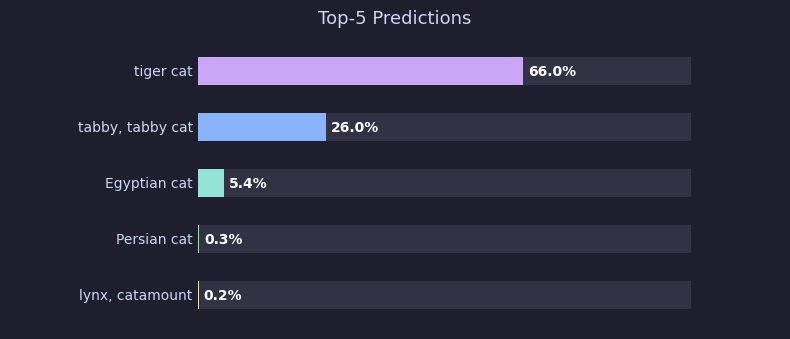

In [18]:
import matplotlib.pyplot as plt
import numpy as np

with open(LABELS_PATH, 'r') as f:
    index_to_label = json.load(f)

labels = [index_to_label[str(int(idx))] for idx in top5_indices]
probs_np = np.array(top5_probabilities, dtype=float)

labels = labels[::-1]
probs_np = probs_np[::-1]

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_h = 0.5
colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af'][::-1]

for i, (label, prob, color) in enumerate(zip(labels, probs_np, colors)):
    ax.barh(i, 1.0, height=bar_h, color='#313244', left=0)
    ax.barh(i, prob,  height=bar_h, color=color,    left=0)
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')
    ax.text(-0.01, i, label, va='center', ha='right',
            color='#cdd6f4', fontsize=10)

ax.set_xlim(-0.38, 1.18)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis('off')
ax.set_title('Top-5 Predictions', color='#cdd6f4', fontsize=13, pad=10)

plt.tight_layout()
plt.show()


### Positional Embedding Similarity Map

ViT learns **1D positional embeddings** but the model has to figure out that position 15 is next to position 16 *and* to position 1 (same row). The similarity map below reveals whether it actually learns 2D spatial structure.

For each of the 196 patch positions, we compute cosine similarity against every other patch position using the raw `pos_embed` weights. Reshaping to 14×14 shows if neighbouring patches have similar embeddings — which they should if the model has learned spatial topology.

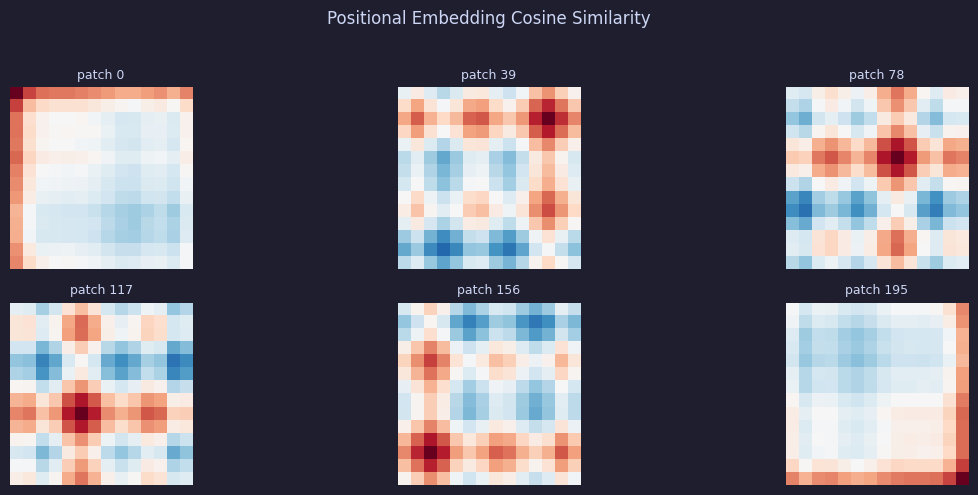

In [19]:
import matplotlib.pyplot as plt
import numpy as np

pos_emb = np.array(m['embeddings']['pos_embed'][0], dtype=np.float32)  # (197, 768)
patch_emb = pos_emb[1:]                                                 # (196, 768) — drop CLS

norms = np.linalg.norm(patch_emb, axis=-1, keepdims=True)
patch_emb_norm = patch_emb / (norms + 1e-8)

num_patches = 6
pick = np.linspace(0, 195, num_patches, dtype=int)

fig, axes = plt.subplots(2, num_patches // 2, figsize=(13, 5))
fig.patch.set_facecolor('#1e1e2e')

for ax, idx in zip(axes.flat, pick):
    sim = (patch_emb_norm @ patch_emb_norm[idx])  # (196,)
    sim_map = sim.reshape(14, 14)
    row, col = idx // 14, idx % 14

    ax.imshow(sim_map, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'patch {idx}', color='#cdd6f4', fontsize=9)
    ax.axis('off')

fig.suptitle('Positional Embedding Cosine Similarity\n', color='#cdd6f4', fontsize=12)
plt.tight_layout()
plt.show()


### Full Probability Distribution

The softmax output covers all 1000 ImageNet classes. Plotting the full distribution (log scale) reveals how confident and peaky the model is — a well-trained ViT concentrates almost all probability mass on a handful of classes, with the rest collapsing towards zero.

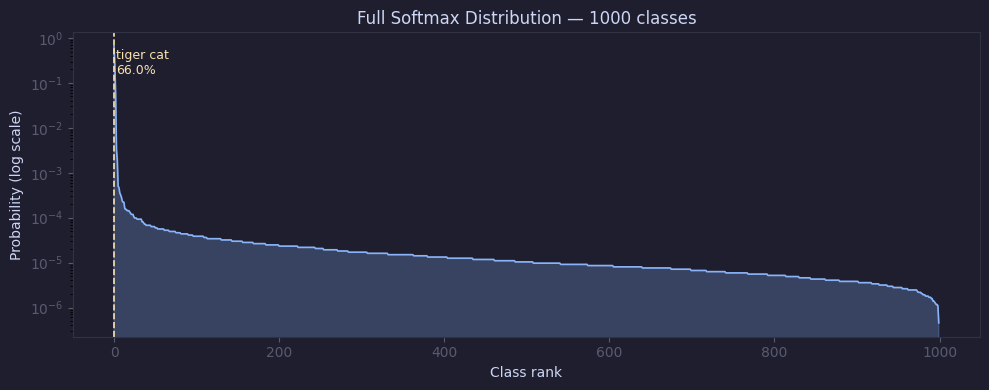

In [20]:
import matplotlib.pyplot as plt
import numpy as np

all_probs = np.array(probs[0], dtype=np.float64)
sorted_probs = np.sort(all_probs)[::-1]

top1_idx = int(top5_indices[0])
top1_label = index_to_label[str(top1_idx)]
top1_prob = float(top5_probabilities[0])

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

x_range = np.arange(len(sorted_probs))
ax.plot(x_range, sorted_probs, color='#89b4fa', linewidth=1.2)
ax.fill_between(x_range, sorted_probs, alpha=0.25, color='#89b4fa')
ax.axvline(0, color='#f9e2af', linewidth=1.2, linestyle='--')
ax.text(2, top1_prob * 0.85, f'{top1_label}\n{top1_prob*100:.1f}%',
        color='#f9e2af', fontsize=9, va='top')

ax.set_yscale('log')
ax.set_xlabel('Class rank', color='#cdd6f4')
ax.set_ylabel('Probability (log scale)', color='#cdd6f4')
ax.set_title('Full Softmax Distribution — 1000 classes', color='#cdd6f4', fontsize=12)
ax.tick_params(colors='#585b70')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()
